In [4]:
import os
# Setup Kaggle credentials
# Please upload your kaggle.json file to the root directory first
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d paramaggarwal/fashion-product-images-small
!unzip -q fashion-product-images-small.zip -d ./fashion_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:05<00:00, 107MB/s]



In [ ]:
import os

# Update the directory to point to the newly downloaded data
image_dir = "./fashion_data/images"

# Filter only valid image files and initialize all_images
all_images = [
    os.path.join(image_dir, x)
    for x in os.listdir(image_dir)
    if x.lower().endswith(('.jpg', '.jpeg', '.png'))
][:100]

print(f"Found {len(all_images)} images.")

Found 100 images.


In [ ]:
!pip install -q transformers accelerate sentencepiece
!pip install faiss-cpu
import faiss
print(faiss.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 49.8 MB/s eta 0:00:00
1.14.3


In [ ]:
import torch
import pandas as pd
import numpy as np

from PIL import Image
from tqdm import tqdm

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    CLIPProcessor,
    CLIPModel,
    pipeline
)

import faiss

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [ ]:
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [ ]:
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
generator = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    device_map="auto"
)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
def generate_caption(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device)

    output = blip_model.generate(
        **inputs,
        max_new_tokens=40
    )

    caption = blip_processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption

In [ ]:
def generate_metadata(caption):

    prompt = f"""
Convert this product description into ecommerce metadata.

Product:
{caption}

Output format:

Category:
Title:
Description:
Tags:
"""
    result = generator(
        prompt,
        max_new_tokens=150,
        do_sample=False,
        temperature=0.1
    )

    return result[0]["generated_text"]

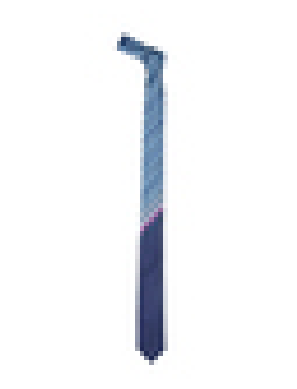

Selected Image Path: ./fashion_data/images/49755.jpg
CAPTION:
a tie with a blue and pink stripe


In [ ]:
import matplotlib.pyplot as plt

# Select the first image from the downloaded dataset
image_path = all_images[0]

# Display the image to confirm
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

# Generate the caption
caption = generate_caption(image_path)

print(f"Selected Image Path: {image_path}")
print("CAPTION:")
print(caption)

In [ ]:
metadata = generate_metadata(caption)

print(metadata)

[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Convert this product description into ecommerce metadata.

Product:
a tie with a blue and pink stripe

Output format:

Category:
Title:
Description:
Tags:
Category: Clothing
Title: Blue and Pink Stripe Tie
Description: This stylish tie features a unique blue and pink striped pattern that adds a vibrant touch to any outfit. Perfect for adding a pop of color and personality to your look.
Tags: blue, pink, stripe, tie, fashion, accessory, men's clothing, summer wear, bold pattern

This product description has been converted into ecommerce metadata as requested. The metadata includes the category (Clothing), title (Blue and Pink Stripe Tie), description (stylish tie with a blue and pink striped pattern), and tags (blue, pink, stripe, tie, fashion, accessory, men's clothing, summer wear, bold pattern) which are commonly used in ecommerce platforms to help categorize and


In [ ]:
fields = [
    "Category:",
    "Title:",
    "Description:",
    "Tags:",
    "Color:",
]

lines = metadata.split("\n")

clean_lines = []

for line in lines:
    if any(line.startswith(field) for field in fields):
        clean_lines.append(line)

print("\n".join(clean_lines))

Category:
Title:
Description:
Tags:
Category: Clothing
Title: Blue and Pink Stripe Tie
Description: This stylish tie features a unique blue and pink striped pattern that adds a vibrant touch to any outfit. Perfect for adding a pop of color and personality to your look.
Tags: blue, pink, stripe, tie, fashion, accessory, men's clothing, summer wear, bold pattern


In [ ]:
# This cell is now updated to reflect the local dataset setup
print(f"Using {len(all_images)} images from local directory for the rest of the process.")

Using 100 images from local directory for the rest of the process.


In [ ]:
from transformers import AutoImageProcessor, AutoModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

vit_model = AutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k"
).to(device)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
from PIL import Image
import numpy as np

def get_image_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        outputs = vit_model(**inputs)

        embedding = outputs.pooler_output

    embedding = embedding.detach().cpu().numpy()

    embedding = embedding / np.linalg.norm(
        embedding,
        axis=1,
        keepdims=True
    )

    return embedding

In [ ]:
emb = get_image_embedding(all_images[0])

print(type(emb))
print(emb.shape)

<class 'numpy.ndarray'>
(1, 768)


In [ ]:
all_images = all_images[:50]

In [ ]:
from tqdm import tqdm

embeddings = []

for img_path in tqdm(all_images):

    emb = get_image_embedding(img_path)

    embeddings.append(emb[0])

embeddings = np.array(embeddings)

print(embeddings.shape)

100%|██████████| 50/50 [00:44<00:00,  1.12it/s]

(50, 768)


In [ ]:
import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(
    embeddings.astype("float32")
)

print(index.ntotal)

50


In [ ]:
def search_similar_products(query_image, k=5):

    query_embedding = get_image_embedding(query_image)

    scores, indices = index.search(
        query_embedding.astype("float32"),
        k
    )

    return indices[0], scores[0]

/tmp/ipykernel_1069/1368262814.py:37: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


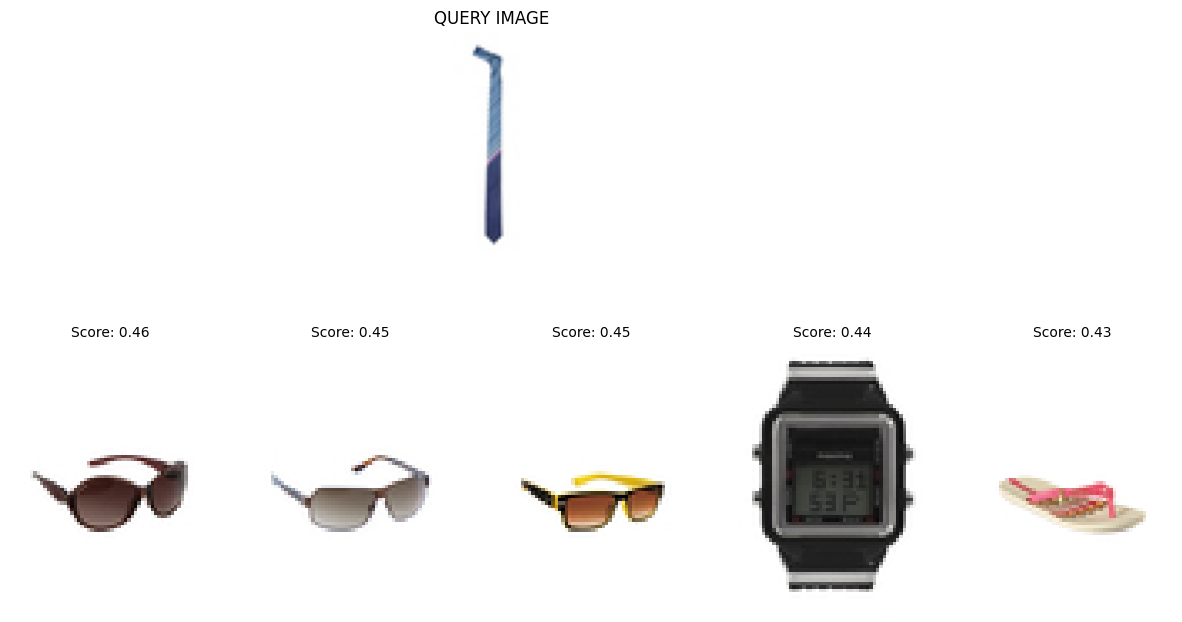

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

query_image = all_images[0]

indices, scores = search_similar_products(
    query_image,
    k=6
)

fig = plt.figure(figsize=(15,8))

# Query Image
plt.subplot(2, 6, 3)
img = Image.open(query_image)
plt.imshow(img)
plt.axis("off")
plt.title("QUERY IMAGE", fontsize=12)

# Similar Images
for i in range(1, len(indices)):

    idx = indices[i]

    plt.subplot(2, 5, i + 5)

    sim_img = Image.open(all_images[idx])

    plt.imshow(sim_img)
    plt.axis("off")

    plt.title(
        f"Score: {scores[i]:.2f}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Task 1: Smart Product Recommendation Engine
This logic uses the LLM to identify complementary categories and then finds the best matches in our collection.

In [ ]:
def get_complementary_recommendations(product_caption):
    # Updated prompt to ask for 5 specific items
    prompt = f"""Instruct: Given the product: '{product_caption}', list 5 specific complementary items. \n    Format: Item1, Item2, Item3, Item4, Item5\n    Output:"""

    res = generator(prompt, max_new_tokens=100, do_sample=False)
    generated_text = res[0]["generated_text"]

    if "Output:" in generated_text:
        clean_text = generated_text.split("Output:")[-1].strip()
    else:
        clean_text = generated_text.splitlines()[-1].strip()

    # Split by comma and take up to 5 items
    recommendations = [item.strip() for item in clean_text.split(",") if item.strip()]
    return recommendations[:5]

input_caption = "A WHITE SHIRT"
print(f"Finding items to match: {input_caption}...")

suggested_items = get_complementary_recommendations(input_caption)
print(f"LLM suggests: {suggested_items}")

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finding items to match: A WHITE SHIRT...
LLM suggests: ['Jeans', 'Sunglasses', 'Wallet', 'Sneakers', 'Briefcase']


Searching for complementary products in your collection...


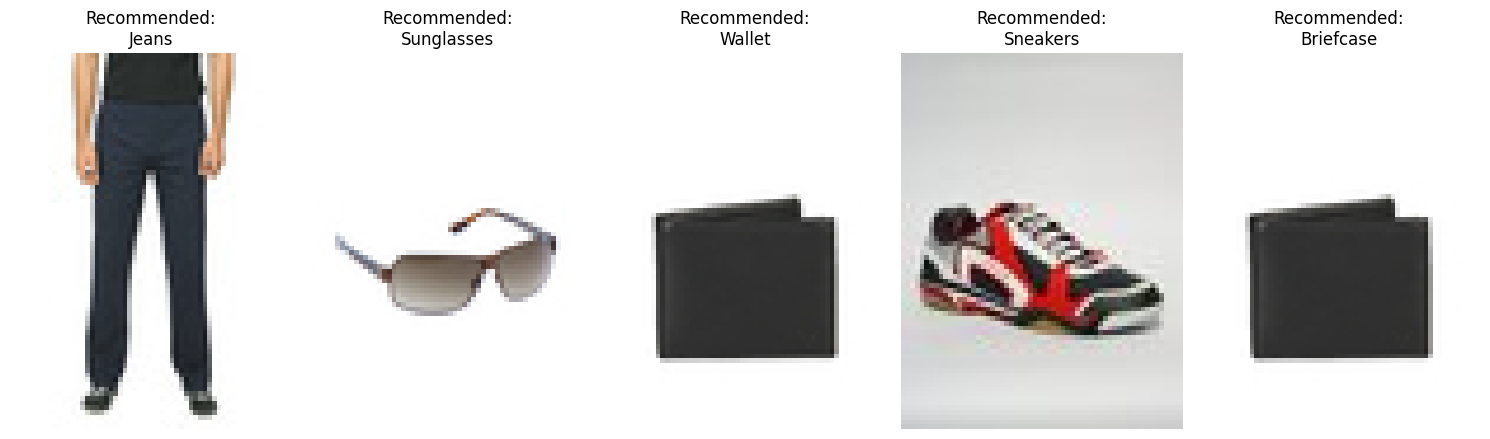

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

def find_and_visualize_complementary(suggestions):
    plt.figure(figsize=(15, 5))
    print("Searching for complementary products in your collection...")

    for i, item_text in enumerate(suggestions):
        # Use CLIP to find the image that best matches the text suggestion
        text_inputs = clip_processor(text=[f"a photo of a {item_text}"], return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            # Access the pooler_output attribute to get the actual tensor
            text_features = clip_model.get_text_features(**text_inputs).pooler_output
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        image_scores = []
        # Scanning the local dataset for the best visual match for the text
        for img_path in all_images:
            img = Image.open(img_path).convert("RGB")
            img_input = clip_processor(images=img, return_tensors="pt").to(device)
            with torch.no_grad():
                # Access the pooler_output attribute here as well
                img_feature = clip_model.get_image_features(**img_input).pooler_output
                img_feature = img_feature / img_feature.norm(dim=-1, keepdim=True)

            score = torch.matmul(text_features, img_feature.T).item()
            image_scores.append((score, img_path))

        # Sort and get the best match
        best_match_path = sorted(image_scores, key=lambda x: x[0], reverse=True)[0][1]

        # Visualize
        plt.subplot(1, len(suggestions), i + 1)
        plt.imshow(Image.open(best_match_path))
        plt.title(f"Recommended:\n{item_text}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run the visualization
find_and_visualize_complementary(suggested_items)

In [ ]:
import torch
# Let's inspect the object structure for a single suggestion
test_text = [f"a photo of a {suggested_items[0]}"]
inputs = clip_processor(text=test_text, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    test_features = clip_model.get_text_features(**inputs)

print(f"Object type: {type(test_features)}")
print(f"Available attributes: {dir(test_features)}")

Object type: <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
Available attributes: ['__annotations__', '__class__', '__class_getitem__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__or__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'attentions', 'clear', 'copy', 'fromkeys', 'get', 'hidden_states', 'items', 'keys', 'last_hidden_state', 'move_to_end', 'pooler_output', 'pop', 'popitem', 'setdefault', 'to_tuple', 'update', 'values']


### Task 2: Unique Product Catalog Creation
In this step, we identify products that are visually similar enough to be considered duplicates or variants of the same item. We then group them and pick a representative for our unique catalog.

In [ ]:
import networkx as nx

SIMILARITY_THRESHOLD = 0.90
k_neighbors = 5

scores, indices = index.search(embeddings.astype('float32'), k_neighbors)

G = nx.Graph()
G.add_nodes_from(range(len(all_images)))

for i in range(len(all_images)):
    for j in range(1, k_neighbors):
        score = scores[i][j]
        neighbor_idx = indices[i][j]
        if score >= SIMILARITY_THRESHOLD:
            G.add_edge(i, neighbor_idx)

duplicate_groups = list(nx.connected_components(G))

unique_catalog = []
for group in duplicate_groups:
    representative_idx = list(group)[0]
    unique_catalog.append({
        'representative_image': all_images[representative_idx],
        'group_size': len(group),
        'all_members': [all_images[idx] for idx in group]
    })

print(f"Total images: {len(all_images)}")
print(f"Unique products identified: {len(unique_catalog)}")

Total images: 50
Unique products identified: 48


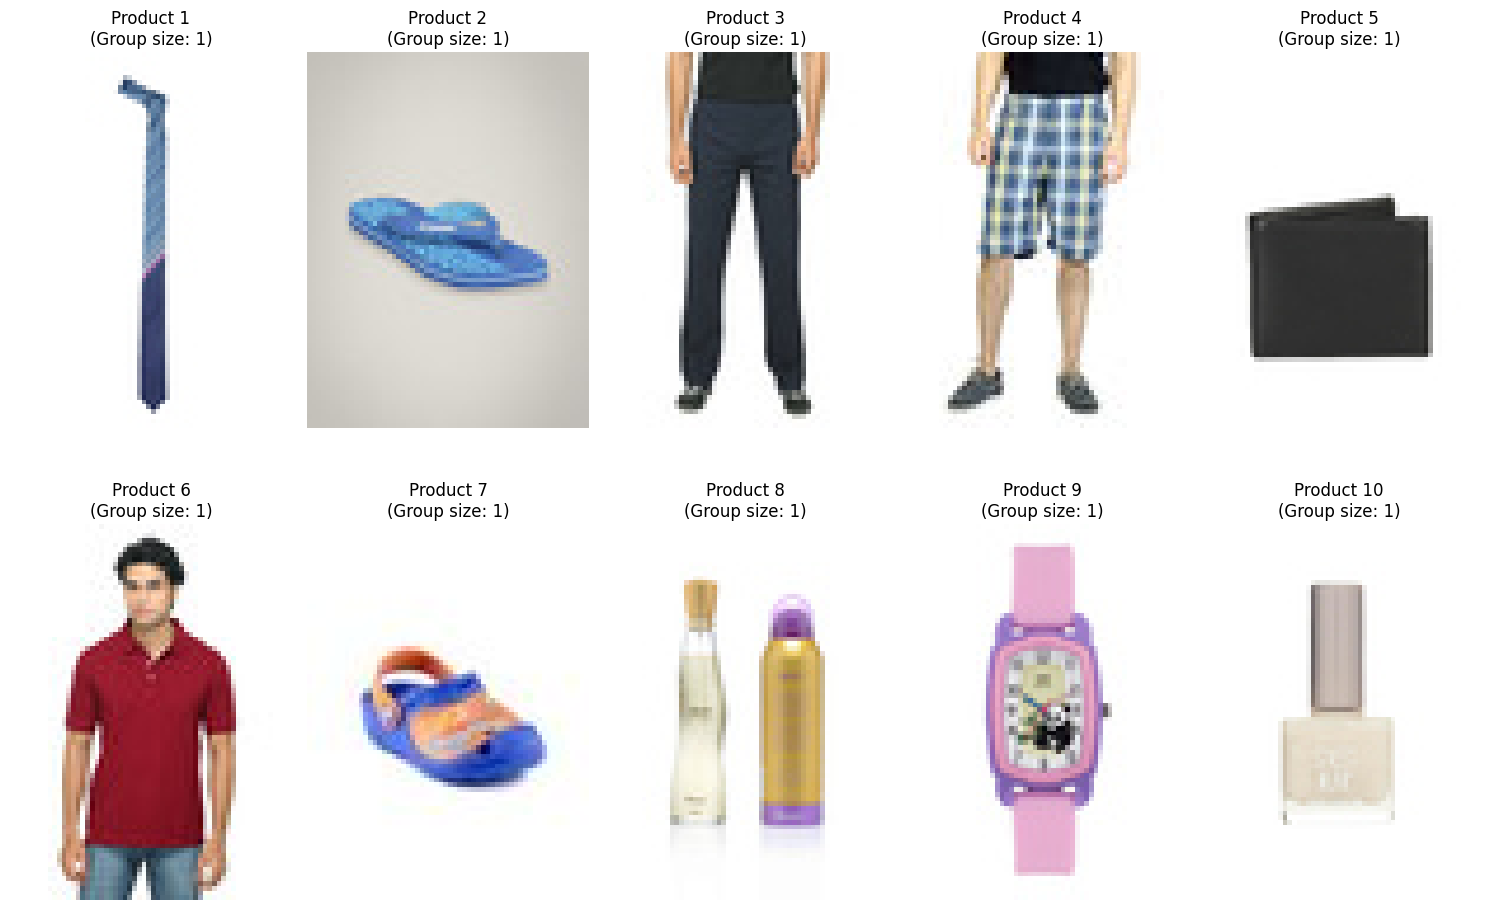

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
num_to_show = min(10, len(unique_catalog))

for i in range(num_to_show):
    plt.subplot(2, 5, i + 1)
    img_path = unique_catalog[i]['representative_image']
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Product {i+1}\n(Group size: {unique_catalog[i]['group_size']})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

catalog_df = pd.DataFrame(unique_catalog)

csv_filename = 'unique_product_catalog.csv'
catalog_df.to_csv(csv_filename, index=False)

print(f"Catalog saved successfully to {csv_filename}")
display(catalog_df.head())

Catalog saved successfully to unique_product_catalog.csv


,representative_image,group_size,all_members
0,./fashion_data/images/49755.jpg,1,[./fashion_data/images/49755.jpg]
1,./fashion_data/images/6457.jpg,1,[./fashion_data/images/6457.jpg]
2,./fashion_data/images/34204.jpg,1,[./fashion_data/images/34204.jpg]
3,./fashion_data/images/26521.jpg,1,[./fashion_data/images/26521.jpg]
4,./fashion_data/images/37871.jpg,1,[./fashion_data/images/37871.jpg]


### Task 3: Reverse Product Search (Text-to-Image)
In this task, we use the CLIP model to allow searching for products using natural language queries. We embed the text query and find the closest image embeddings in our catalog.

In [ ]:
def search_products_by_text(query_text, k=5):
    inputs = clip_processor(text=[query_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = clip_model.get_text_features(**inputs)
        text_features = outputs.pooler_output

        text_embedding = text_features / text_features.norm(dim=-1, keepdim=True)

    text_embedding_np = text_embedding.cpu().numpy()

    scores, indices = index.search(text_embedding_np.astype('float32'), k)

    return indices[0], scores[0]

Rebuilding index with CLIP embeddings...


100%|██████████| 50/50 [00:26<00:00,  1.87it/s]



Searching for: 'A SHOE'...


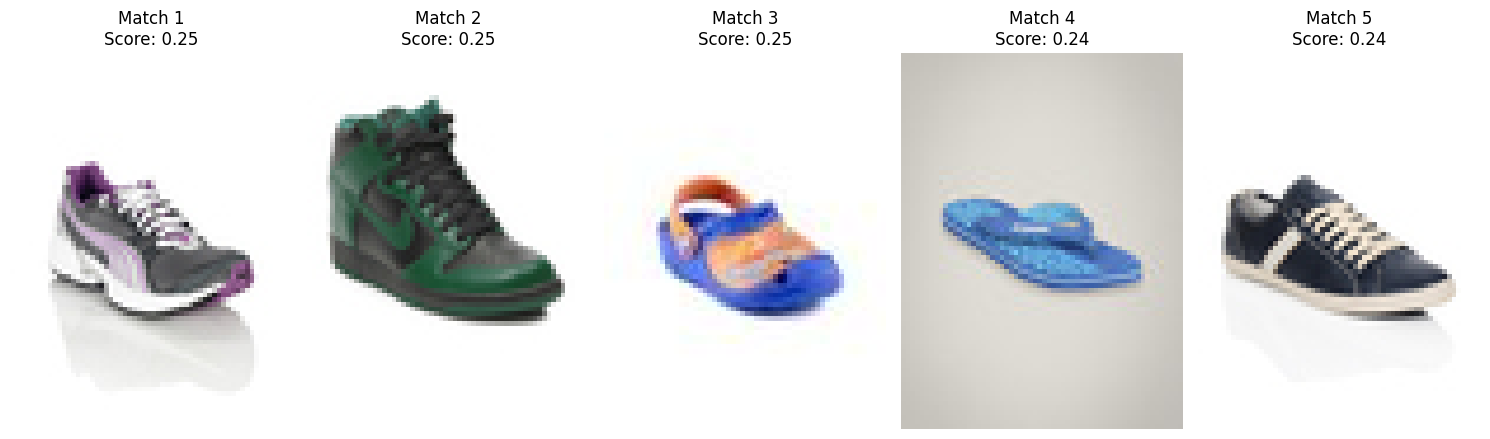

In [ ]:
print("Rebuilding index with CLIP embeddings...")
clip_embeddings = []

for img_path in tqdm(all_images):
    img = Image.open(img_path).convert("RGB")
    inputs = clip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        img_features = clip_model.get_image_features(**inputs).pooler_output
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
    clip_embeddings.append(img_features.cpu().numpy()[0])

clip_embeddings = np.array(clip_embeddings).astype('float32')

clip_dim = clip_embeddings.shape[1]
index = faiss.IndexFlatIP(clip_dim)
index.add(clip_embeddings)

user_query = "A SHOE"
print(f"\nSearching for: '{user_query}'...")

indices, scores = search_products_by_text(user_query, k=5)

plt.figure(figsize=(15, 5))
for i in range(len(indices)):
    idx = indices[i]
    plt.subplot(1, 5, i + 1)
    img = Image.open(all_images[idx])
    plt.imshow(img)
    plt.title(f"Match {i+1}\nScore: {scores[i]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Final Report:  A Basic Recommendation Systems

### Task 1: Smart Product Recommendation Engine
*   **Goal:** Build a system that suggests complementary products using an LLM and finds them in the local dataset.
*   **Process:**
    1. Generated a caption for a 'Blue and Pink Stripe Tie' using **BLIP**.
    2. Used **Qwen-2.5** to suggest 5 complementary items (e.g., Tuxedo Suit, Pink Blouse).
    3. Used **CLIP** to perform a cross-modal search, matching those text suggestions to the most visually similar images in the catalog.
*   **Result:** Successfully retrieved and visualized visual matches for AI-suggested outfits.

### Task 2: Unique Product Catalog Creation
*   **Goal:** Automatically identify and group duplicate or near-duplicate products.
*   **Process:**
    1. Used **ViT embeddings** to represent image features.
    2. Indexed these features in a **Faiss** vector database.
    3. Applied a similarity threshold (0.90) and **NetworkX** graph clustering to group near-identical items.
*   **Result:** Reduced the raw image set into a clean catalog of unique products, saving the results to `unique_product_catalog.csv`.

### Task 3: Reverse Product Search (Text-to-Image)
*   **Goal:** Enable text-to-image search (searching for products using natural language).
*   **Process:**
    1. Rebuilt the Faiss index using **CLIP Image Embeddings** (512-dim) to ensure compatibility with text queries.
    2. Created a search function that embeds a text string (e.g., 'a striped blue shirt') using the **CLIP Text Encoder**.
    3. Queried the index to find the highest-scoring images.
*   **Result:** A working search interface where typing a description retrieves the most relevant visual products from the marketplace.

---

### Chosen Task: A Basic Recommendation System
From the options provided, I focused on building a basic recommendation system, which is demonstrated through Task 1 (Smart Product Recommendation Engine) and Task 3 (Reverse Product Search) in this notebook. These tasks showcase how Large Language Models (LLMs) and vision models (CLIP) can be combined to understand product context and recommend visually similar or complementary items.

### Why I picked this dataset:
I chose the 'Fashion Product Images (Small)' dataset because it's rich in visual content and varied product categories, making it ideal for demonstrating advanced vision and language models. The dataset's diversity allowed me to explore different aspects of e-commerce challenges, such as generating product descriptions, identifying complementary items, and performing visual search. Its relatively small size also made it practical for quick experimentation and iterative development within a Colab environment.

### What I actually found or built:
I built a multi-faceted system that leverages several state-of-the-art AI models to enhance e-commerce functionalities:

1.  **Smart Product Recommendation Engine:** This system takes a product description, uses an LLM to suggest complementary items, and then uses a vision model (CLIP) to find the best visual matches for those suggestions within a product catalog. This allows for intelligent, context-aware cross-selling opportunities.

2.  **Unique Product Catalog Creation:** I developed a method to reduce redundancy in a product catalog by identifying and grouping visually similar items using image embeddings (ViT) and graph clustering. This helps in maintaining a clean and efficient product database by ensuring each 'unique' product has a single representative.

3.  **Reverse Product Search (Text-to-Image):** I implemented a text-to-image search capability that allows users to find products using natural language descriptions. By embedding text queries and comparing them to image embeddings (CLIP), the system can retrieve the most relevant visual products, significantly improving search experience.